In [16]:
import pandas as pd
import numpy as np
import os
import sys
%load_ext autoreload
%autoreload 2
# sys.path.append('/home/wolfgang/repos/sleep_research_io')
# from sleep_research_functions import *
# %matplotlib widget
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from icu_sleep_breathing_2020_help_functions import * 

pd.options.display.max_rows = 300
pd.options.display.max_columns = 300

font = {'family' : 'normal',
        'weight' : 'normal',
        'size'   : 8}

matplotlib.rc('font', **font)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### load summary tables:

In [17]:
plots_savedir = '/media/mad3/Projects/ICU_SLEEP_STUDY/Sleep_And_Breathing/plots'
if not os.path.exists(plots_savedir):
    plots_savedir = 'C:/Users/Wolfgang/Dropbox (Partners HealthCare)/SleepInICUandSleeplabPaper/Plots'

In [18]:
[summary_subjects_icu, summary_subjects_sleeplab, 
 summary_days_icu, summary_days_sleeplab] = load_summary_data_with_inclusion_criteria(sleeplab_matched=True)

# of subjects ICU before inclusion criteria: 108
# of 12-hour segments ICU before inclusion criteria: 1230
# of subjects ICU after inclusion criteria: 103
# of 12-hour segments ICU after inclusion criteria: 621
24-hour segments: 256
12-hour segments: 365

# of subjects sleeplab before inclusion criteria: 307
# of 12-hour segments sleeplab before inclusion criteria: 307
# of subjects sleeplab after inclusion criteria: 307
# of 12-hour segments sleeplab after before inclusion criteria: 307


In [19]:
for modality in ['breathing', 'ecg_nn']:
    var_n2 = 'stages_distribution_MODALITY_N2'.replace('MODALITY', modality)
    var_n3 = 'stages_distribution_MODALITY_N3'.replace('MODALITY', modality)
    var_sum = 'stages_distribution_MODALITY_N2N3'.replace('MODALITY', modality)
    
    summary_days_icu[var_sum] = summary_days_icu[var_n2] + summary_days_icu[var_n3]
    summary_days_sleeplab[var_sum] = summary_days_sleeplab[var_n2] + summary_days_sleeplab[var_n3]

In [20]:
summary_days_icu.loc[:, ['stages_distribution' in x for x in summary_days_icu.columns]] *= 100
summary_days_sleeplab.loc[:, ['stages_distribution' in x for x in summary_days_sleeplab.columns]] *= 100

summary_f_icu = summary_days_icu.loc[summary_days_icu.day_cat == 'f', :]
summary_dn_icu = summary_days_icu.loc[summary_days_icu.day_cat != 'f', :]

summary_days_sleeplab_full = summary_days_sleeplab.copy()

In [59]:
summary_days_icu_n = summary_days_icu.loc[summary_days_icu.day_cat == 'n', :]

summary_days_sleeplab = summary_days_sleeplab_full.loc[summary_days_sleeplab_full.matched_all == 1].copy()

min_hours_sleep_icu = 4
icu_4 = summary_dn_icu.loc[np.any([summary_dn_icu.sleep_hours_breathing >= min_hours_sleep_icu, 
                                               summary_dn_icu.sleep_hours_ecg_nn >= min_hours_sleep_icu],
                                               axis=0), :]

icu_4_strict = summary_dn_icu.loc[np.all([summary_dn_icu.sleep_hours_breathing >= min_hours_sleep_icu, 
                                               summary_dn_icu.sleep_hours_ecg_nn >= min_hours_sleep_icu],
                                               axis=0), :]


icu_version = 'icu_full_4'

if icu_version == 'icu_4_strict':
    Xy_icu = icu_4_strict.copy()
    suptitle = f'ICU data with >4 hour sleep prediction for both models.\nn_sleeplab = {Xy_sleeplab.shape[0]} n_icu = {Xy_icu.shape[0]}'
elif icu_version == 'icu_4':
    Xy_icu = icu_4.copy()
    suptitle = f'ICU data with >4 hour sleep prediction for any of the two models.\nn_sleeplab = {Xy_sleeplab.shape[0]} n_icu = {Xy_icu.shape[0]}'
elif icu_version == 'summary_days_icu_n':
    Xy_icu = summary_days_icu_n.copy()
    suptitle = f'ICU data with all night segments.\nn_sleeplab = {Xy_sleeplab.shape[0]} n_icu = {Xy_icu.shape[0]}'
elif icu_version == 'summary_dn_icu':
    Xy_icu = summary_dn_icu.copy()
    suptitle = f'ICU data with all 12-hour segments.\nn_sleeplab = {Xy_sleeplab.shape[0]} n_icu = {Xy_icu.shape[0]}'
elif icu_version == 'icu_full_4':
    min_hours_sleep_icu = 4
    Xy_icu =  summary_days_icu.loc[np.all([summary_days_icu.day_cat == 'f', 
                                           summary_days_icu.sleep_hours_breathing >= min_hours_sleep_icu, 
                                               summary_days_icu.sleep_hours_ecg_nn >= min_hours_sleep_icu],
                                               axis=0), :].copy()
    suptitle = f'ICU data with 24-hour segments and >4hours of sleep for both models.\nn_sleeplab = {Xy_sleeplab.shape[0]} n_icu = {Xy_icu.shape[0]}'

print(f'ICU Version = {icu_version}')
print(suptitle)


sleeplab_version = 'matched'

if sleeplab_version == 'matched':
    Xy_sleeplab = summary_days_sleeplab_full.loc[summary_days_sleeplab_full['matched_all'] == 1].copy()
    


ICU Version = icu_full_4
ICU data with 24-hour segments and >4hours of sleep for both models.
n_sleeplab = 220 n_icu = 111


In [60]:
ahi_categories = ['all', 'ahi_0_5', 'ahi_5_15', 'ahi_15_30', 'ahi_30_100', 'ahi_15_100']
ahi_names = {
    'all': 'All',
    'ahi_0_5': 'AHI < 5',
    'ahi_5_15': '5 < AHI <=15',
    'ahi_15_30': '15 < AHI <= 30',
    'ahi_30_100': 'AHI > 30',
    'ahi_15_100': 'AHI > 15',
}

variables_template = ['stages_distribution_MODALITY_S',
             'stages_distribution_MODALITY_R',
             'stages_distribution_MODALITY_N1',
            'stages_distribution_MODALITY_N2',
             'stages_distribution_MODALITY_N3',
            'stages_distribution_MODALITY_N2N3',
#             'sleep_hours_MODALITY',
#              'sleep_MODALITY_sfi',
#              'sleep_MODALITY_sfi_w',
#              'sleep_MODALITY_arousali',
            ]
var_names = ['Sleep Dur (%)', 'Stage R (%)', 'Stage N1 (%)', 'Stage N2 (%)', 'Stage N3 (%)', 'Stage N2+N3 (%)'] # , 'Sleep Dur. (h)', 'SFI', 'SFI Wake', 'Arousal I.']

In [61]:
[x for x in Xy_icu.columns if 'R' in x]

['stages_distribution_breathing_R',
 'stages_distribution_ecg_nn_R',
 'stages_distribution_expert_R']

In [68]:
var_names = ['Sleep Dur (%)', 'Stage R (%)', 'Stage N1 (%)', 'Stage N2 (%)', 'Stage N3 (%)', 'Stage N2+N3 (%)'] # , 'Sleep Dur. (h)', 'SFI', 'SFI Wake', 'Arousal I.']
n_vars = len(var_names)

for i_var in range(n_vars):
    
    var_tmp = variables_template[i_var]
    var_name_tmp = var_names[i_var]
    var_ecg = var_tmp.replace('MODALITY', 'ecg_nn')
    var_resp = var_tmp.replace('MODALITY', 'breathing')
    
    var_ecg_icu = Xy_icu[var_ecg].values
    var_resp_icu = Xy_icu[var_resp].values
    
    var_diff_abs_icu = var_resp_icu - var_ecg_icu
    var_abs_diff_icu_large = np.abs(var_diff_abs_icu) > -1
    var_diff_rel_icu =  (var_resp_icu[var_abs_diff_icu_large] + 1e-3)/ (var_ecg_icu[var_abs_diff_icu_large] + 1e-3)
    var_sum_icu =  (var_resp_icu[var_abs_diff_icu_large] + 1e-3) + (var_ecg_icu[var_abs_diff_icu_large] + 1e-3)

    Xy_icu[var_tmp.replace('MODALITY', 'diff_abs')] = var_diff_abs_icu
    Xy_icu[var_tmp.replace('MODALITY', 'diff_rel')] = var_diff_rel_icu
    Xy_icu[var_tmp.replace('MODALITY', 'sum')] = var_sum_icu


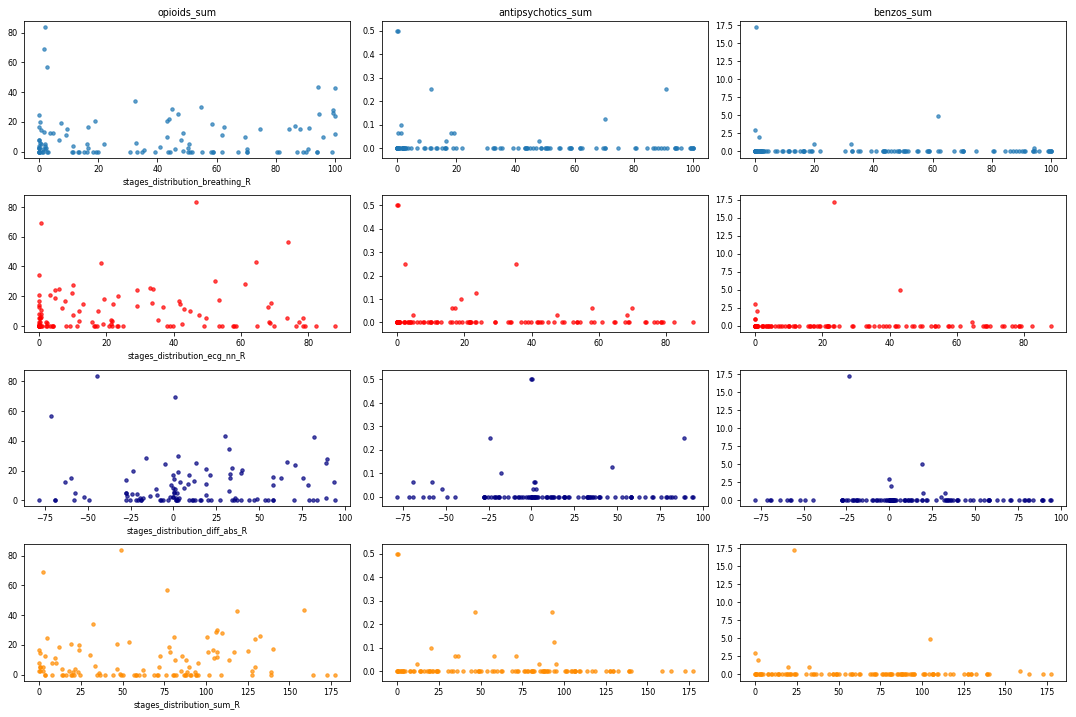

In [122]:
fig, ax = plt.subplots(4,3, figsize=(15,10))
x = 'stages_distribution_breathing_R'
y = 'opioids_sum'
ax[0,0].scatter(Xy_icu[x], Xy_icu[y], s=12, alpha=0.7)
ax[0,0].set_title(y)
ax[0,0].set_xlabel(x)
y = 'antipsychotics_sum'
ax[0,1].scatter(Xy_icu[x], Xy_icu[y], s=12, alpha=0.7)
ax[0,1].set_title(y)
y = 'benzos_sum'
ax[0,2].scatter(Xy_icu[x], Xy_icu[y], s=12, alpha=0.7)
ax[0,2].set_title(y)

x = 'stages_distribution_ecg_nn_R'
color = 'red'

y = 'opioids_sum'
ax[1,0].scatter(Xy_icu[x], Xy_icu[y], s=12, alpha=0.7, color=color)
ax[1,0].set_xlabel(x)
y = 'antipsychotics_sum'
ax[1,1].scatter(Xy_icu[x], Xy_icu[y], s=12, alpha=0.7, color=color)
y = 'benzos_sum'
ax[1,2].scatter(Xy_icu[x], Xy_icu[y], s=12, alpha=0.7, color=color)


x = 'stages_distribution_diff_abs_R'
color = 'navy'

y = 'opioids_sum'
ax[2,0].scatter(Xy_icu[x], Xy_icu[y], s=12, alpha=0.7, color=color)
ax[2,0].set_xlabel(x)
y = 'antipsychotics_sum'
ax[2,1].scatter(Xy_icu[x], Xy_icu[y], s=12, alpha=0.7, color=color)
y = 'benzos_sum'
ax[2,2].scatter(Xy_icu[x], Xy_icu[y], s=12, alpha=0.7, color=color)


x = 'stages_distribution_sum_R'
color = 'darkorange'

y = 'opioids_sum'
ax[3,0].scatter(Xy_icu[x], Xy_icu[y], s=12, alpha=0.7, color=color)
ax[3,0].set_xlabel(x)
y = 'antipsychotics_sum'
ax[3,1].scatter(Xy_icu[x], Xy_icu[y], s=12, alpha=0.7, color=color)
y = 'benzos_sum'
ax[3,2].scatter(Xy_icu[x], Xy_icu[y], s=12, alpha=0.7, color=color)
plt.tight_layout()
plt.savefig(os.path.join(plots_savedir, f'Figure_R_and_Meds.jpg'), dpi=500)
plt.savefig(os.path.join(plots_savedir, f'Figure_R_and_Meds.svg'))

In [52]:
y = 'opioids_sum'
np.corrcoef(Xy_icu[x], Xy_icu[y])[0,1]

0.04866992545845269

In [115]:
import seaborn as sns
color_boxplot = 'white'
color_swarme = np.array([255,185,0])/255 # 'gold'
color_swarmf= np.array([255,185,0])/255 # 'gold'
swarmsize = 2
swarmalpha = 0.8 

/home/wolfgang/anaconda3/envs/analysis/lib/python3.6/site-packages/seaborn/categorical.py:3000: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if edgecolor == "gray":
/home/wolfgang/anaconda3/envs/analysis/lib/python3.6/site-packages/seaborn/categorical.py:1296: UserWarning: 24.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/wolfgang/anaconda3/envs/analysis/lib/python3.6/site-packages/seaborn/categorical.py:3000: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if edgecolor == "gray":
/home/wolfgang/anaconda3/envs/analysis/lib/python3.6/site-packages/seaborn/categorical.py:1296: UserWarning: 12.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


t-test (Welch): p-value:        0.650
Mann Whiteney U test: p-value:  0.134
t-test (Welch): p-value:        0.356
Mann Whiteney U test: p-value:  0.304


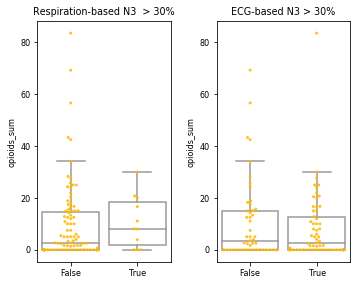

In [148]:
threshold = 30
y = 'opioids_sum'
stage_name = 'N3'

fig, ax = plt.subplots(1,2, figsize=(5,4))

i_axis = 0
x = 'stages_distribution_breathing_' + stage_name
Xy_icu['threshold'] = Xy_icu[x] >= threshold
ax[i_axis] = sns.boxplot(x ='threshold', y=y, data=Xy_icu, width=0.85, fliersize=0, color=color_boxplot, saturation=1, ax=ax[i_axis])
ax[i_axis] = sns.swarmplot(x ='threshold', y=y, data=Xy_icu, color=color_swarmf, edgecolor=color_swarme, linewidth=1, size=swarmsize, alpha = swarmalpha, ax=ax[i_axis])
ax[i_axis].set_title(f'Respiration-based {stage_name}  > {threshold}%')
t_statistic, p_value = ttest_ind(Xy_icu.loc[Xy_icu[x] >= threshold, y].values,
                                 Xy_icu.loc[Xy_icu[x] < threshold, y].values, equal_var=False)
print(f't-test (Welch): p-value:        {p_value:.3f}')
t_statistic, p_value = mannwhitneyu(Xy_icu.loc[Xy_icu[x] >= threshold, y].values,
                                 Xy_icu.loc[Xy_icu[x] < threshold, y].values)
print(f'Mann Whiteney U test: p-value:  {p_value:.3f}')
ax[i_axis].set_xlabel('')

i_axis = 1
x = 'stages_distribution_ecg_nn_' + stage_name
Xy_icu['threshold'] = Xy_icu[x] >= threshold
ax[i_axis] = sns.boxplot(x ='threshold', y=y, data=Xy_icu, width=0.85, fliersize=0, color=color_boxplot, saturation=1, ax=ax[i_axis])
ax[i_axis] = sns.swarmplot(x ='threshold', y=y, data=Xy_icu, color=color_swarmf, edgecolor=color_swarme, linewidth=1, size=swarmsize, alpha = swarmalpha, ax=ax[i_axis])
ax[i_axis].set_title(f'ECG-based {stage_name} > {threshold}%')
t_statistic, p_value = ttest_ind(Xy_icu.loc[Xy_icu[x] >= threshold, y].values,
                                 Xy_icu.loc[Xy_icu[x] < threshold, y].values, equal_var=False)
print(f't-test (Welch): p-value:        {p_value:.3f}')
t_statistic, p_value = mannwhitneyu(Xy_icu.loc[Xy_icu[x] >= threshold, y].values,
                                 Xy_icu.loc[Xy_icu[x] < threshold, y].values)
print(f'Mann Whiteney U test: p-value:  {p_value:.3f}')
ax[i_axis].set_xlabel('')

plt.tight_layout()
plt.savefig(os.path.join(plots_savedir, f'Figure_{stage_name}_and_Opioid_threshold_{threshold}.jpg'), dpi=500)
plt.savefig(os.path.join(plots_savedir, f'Figure_{stage_name}_and_Opioid_threshold_{threshold}.svg'))

In [158]:
# offtopic: use same plot thingy for SOFA

/home/wolfgang/anaconda3/envs/analysis/lib/python3.6/site-packages/seaborn/categorical.py:3000: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if edgecolor == "gray":
/home/wolfgang/anaconda3/envs/analysis/lib/python3.6/site-packages/seaborn/categorical.py:1296: UserWarning: 20.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/wolfgang/anaconda3/envs/analysis/lib/python3.6/site-packages/seaborn/categorical.py:3000: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if edgecolor == "gray":
/home/wolfgang/anaconda3/envs/analysis/lib/python3.6/site-packages/seaborn/categorical.py:1296: UserWarning: 17.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/wo

t-test (Welch): p-value:        0.631
Mann Whiteney U test: p-value:  0.476
t-test (Welch): p-value:        0.131
Mann Whiteney U test: p-value:  0.053
t-test (Welch): p-value:        0.013
Mann Whiteney U test: p-value:  0.003


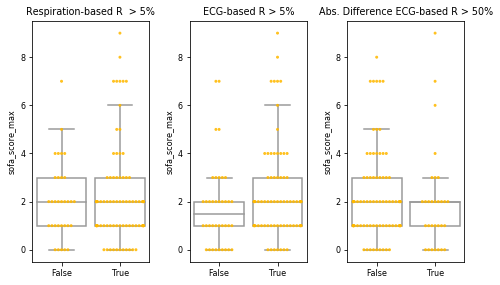

In [160]:
threshold = 5
y = 'sofa_score_max'
stage_name = 'R'

fig, ax = plt.subplots(1,3, figsize=(7,4))

i_axis = 0
x = 'stages_distribution_breathing_' + stage_name
Xy_icu['threshold'] = Xy_icu[x] >= threshold
ax[i_axis] = sns.boxplot(x ='threshold', y=y, data=Xy_icu, width=0.85, fliersize=0, color=color_boxplot, saturation=1, ax=ax[i_axis])
ax[i_axis] = sns.swarmplot(x ='threshold', y=y, data=Xy_icu, color=color_swarmf, edgecolor=color_swarme, linewidth=1, size=swarmsize, alpha = swarmalpha, ax=ax[i_axis])
ax[i_axis].set_title(f'Respiration-based {stage_name}  > {threshold}%')
t_statistic, p_value = ttest_ind(Xy_icu.loc[Xy_icu[x] >= threshold, y].values,
                                 Xy_icu.loc[Xy_icu[x] < threshold, y].values, equal_var=False)
print(f't-test (Welch): p-value:        {p_value:.3f}')
t_statistic, p_value = mannwhitneyu(Xy_icu.loc[Xy_icu[x] >= threshold, y].values,
                                 Xy_icu.loc[Xy_icu[x] < threshold, y].values)
print(f'Mann Whiteney U test: p-value:  {p_value:.3f}')
ax[i_axis].set_xlabel('')

i_axis = 1
x = 'stages_distribution_ecg_nn_' + stage_name
Xy_icu['threshold'] = Xy_icu[x] >= threshold
ax[i_axis] = sns.boxplot(x ='threshold', y=y, data=Xy_icu, width=0.85, fliersize=0, color=color_boxplot, saturation=1, ax=ax[i_axis])
ax[i_axis] = sns.swarmplot(x ='threshold', y=y, data=Xy_icu, color=color_swarmf, edgecolor=color_swarme, linewidth=1, size=swarmsize, alpha = swarmalpha, ax=ax[i_axis])
ax[i_axis].set_title(f'ECG-based {stage_name} > {threshold}%')
t_statistic, p_value = ttest_ind(Xy_icu.loc[Xy_icu[x] >= threshold, y].values,
                                 Xy_icu.loc[Xy_icu[x] < threshold, y].values, equal_var=False)
print(f't-test (Welch): p-value:        {p_value:.3f}')
t_statistic, p_value = mannwhitneyu(Xy_icu.loc[Xy_icu[x] >= threshold, y].values,
                                 Xy_icu.loc[Xy_icu[x] < threshold, y].values)
print(f'Mann Whiteney U test: p-value:  {p_value:.3f}')
ax[i_axis].set_xlabel('')

i_axis = 2
threshold_diff = 50
x = 'stages_distribution_diff_abs_' + stage_name
Xy_icu['threshold'] = Xy_icu[x].abs() >= threshold_diff
ax[i_axis] = sns.boxplot(x ='threshold', y=y, data=Xy_icu, width=0.85, fliersize=0, color=color_boxplot, saturation=1, ax=ax[i_axis])
ax[i_axis] = sns.swarmplot(x ='threshold', y=y, data=Xy_icu, color=color_swarmf, edgecolor=color_swarme, linewidth=1, size=swarmsize, alpha = swarmalpha, ax=ax[i_axis])
ax[i_axis].set_title(f'Abs. Difference ECG-based {stage_name} > {threshold_diff}%')
t_statistic, p_value = ttest_ind(Xy_icu.loc[Xy_icu[x] >= threshold_diff, y].values,
                                 Xy_icu.loc[Xy_icu[x] < threshold_diff, y].values, equal_var=False)
print(f't-test (Welch): p-value:        {p_value:.3f}')
t_statistic, p_value = mannwhitneyu(Xy_icu.loc[Xy_icu[x] >= threshold_diff, y].values,
                                 Xy_icu.loc[Xy_icu[x] < threshold_diff, y].values)
print(f'Mann Whiteney U test: p-value:  {p_value:.3f}')
ax[i_axis].set_xlabel('')


plt.tight_layout()
# plt.savefig(os.path.join(plots_savedir, f'Figure_{stage_name}_and_Opioid_threshold_{threshold}.jpg'), dpi=500)
# plt.savefig(os.path.join(plots_savedir, f'Figure_{stage_name}_and_Opioid_threshold_{threshold}.svg'))